# Network Anomaly Detection using CICIDS2017 Dataset

This notebook builds a Machine Learning based Network Intrusion Detection System using the CICIDS2017 dataset and Random Forest Classifier.

## 1. Import Required Libraries

In [1]:
import os
import glob
import joblib
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

## 2. Define Project Paths
Model and report directories are created to store trained models, encoders, metrics, and visualizations.

In [2]:
DATA_PATH = "../data/CICIDS-2017"
MODEL_DIR = "../models"
REPORT_DIR = "../reports"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

In [4]:
print(os.getcwd())

C:\Users\adity\Network Anamoly Detection\notebooks


In [5]:
print(os.listdir("."))

['.ipynb_checkpoints', 'cicids2017_model_train.ipynb']


In [6]:
DATA_PATH = "../data/CICIDS-2017"
print(os.listdir(DATA_PATH))

['.ipynb_checkpoints', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']


## 4. Load CICIDS2017 Dataset Files
All CSV files from the CICIDS2017 dataset folder are loaded and combined into a single dataframe.

In [7]:

DATA_PATH = "../data/CICIDS-2017"

csv_files = glob.glob(os.path.join(DATA_PATH, "*.csv"))

print(f"Found {len(csv_files)} CSV files")

df_list = []

for file in csv_files:
    print("Loading:", os.path.basename(file))
    temp_df = pd.read_csv(file, low_memory=False)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

print("Final dataset shape:", df.shape)
df.head()

Found 8 CSV files
Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Final dataset shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 5. Dataset Overview
This section displays dataset shape, column names, data types, and basic information.

In [8]:
# Dataset information
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Shape: (2830743, 79)

Column Names:
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Co

## 6. Target Label Distribution
The distribution of normal and attack traffic labels is checked before preprocessing.

In [9]:
# Check target labels
print(df[" Label"].value_counts())

 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [10]:
print(df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

## 7. Data Cleaning
Duplicate records are removed to improve model quality and avoid biased training.

In [11]:
# Remove duplicate rows
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after duplicate removal:", df.shape)

# Replace Infinity values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove missing values
print("Missing values before:")
print(df.isnull().sum().sum())

df.dropna(inplace=True)

print("\nMissing values after:")
print(df.isnull().sum().sum())

print("\nFinal Shape:", df.shape)

Duplicates before: 308381
Shape after duplicate removal: (2522362, 79)
Missing values before:
3128

Missing values after:
0

Final Shape: (2520798, 79)


## 8. Binary Label Conversion
The CICIDS2017 labels are converted into binary classes:
- `BENIGN` → Normal Traffic
- Other attack labels → Attack Traffic

In [12]:
df[" Label"] = df[" Label"].str.strip()

# Binary Classification
df[" Label"] = df[" Label"].apply(
    lambda x: "BENIGN" if x=="BENIGN" else "ATTACK"
)

print(df[" Label"].value_counts())

 Label
BENIGN    2095057
ATTACK     425741
Name: count, dtype: int64


## 9. Label Encoding
The target labels are encoded into numerical format for machine learning.

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df[" Label"] = le.fit_transform(df[" Label"])

print(df[" Label"].value_counts())

print(le.classes_)

 Label
1    2095057
0     425741
Name: count, dtype: int64
['ATTACK' 'BENIGN']


## 10. Feature and Target Separation
The dataset is separated into input features `X` and target label `y`.

In [14]:
X = df.drop(" Label", axis=1)
y = df[" Label"]

print(X.shape)
print(y.shape)

(2520798, 78)
(2520798,)


## 11. Train-Test Split
The dataset is split into training and testing sets using stratified sampling.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (2016638, 78)
Testing Shape  : (504160, 78)


## 12. Random Forest Model Training
Random Forest Classifier is trained to classify network traffic as normal or attack.

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

print("Training started...")

rf.fit(X_train, y_train)

print("Training Completed!")

Training started...
Training Completed!


## 13. Model Prediction
The trained model is used to predict labels for the test dataset.

In [17]:
y_pred = rf.predict(X_test)

## 14. Accuracy Evaluation

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy: {:.2f}%".format(accuracy * 100))

Random Forest Accuracy: 99.89%


## 15. Overfitting Check
Training accuracy and testing accuracy are compared to check generalization.

In [19]:
train_accuracy = rf.score(X_train, y_train)
test_accuracy = rf.score(X_test, y_test)

print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))
print("Testing Accuracy : {:.2f}%".format(test_accuracy * 100))
print("Difference       : {:.2f}%".format((train_accuracy - test_accuracy) * 100))

Training Accuracy: 99.91%
Testing Accuracy : 99.89%
Difference       : 0.02%


## 16. Precision, Recall and F1 Score

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9989
Precision: 0.9997
Recall   : 0.9989
F1 Score : 0.9993


## 17. Classification Report

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["ATTACK", "BENIGN"]))

              precision    recall  f1-score   support

      ATTACK       0.99      1.00      1.00     85148
      BENIGN       1.00      1.00      1.00    419012

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160



## 18. Confusion Matrix

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 85038    110]
 [   468 418544]]


## 19. Confusion Matrix Visualization

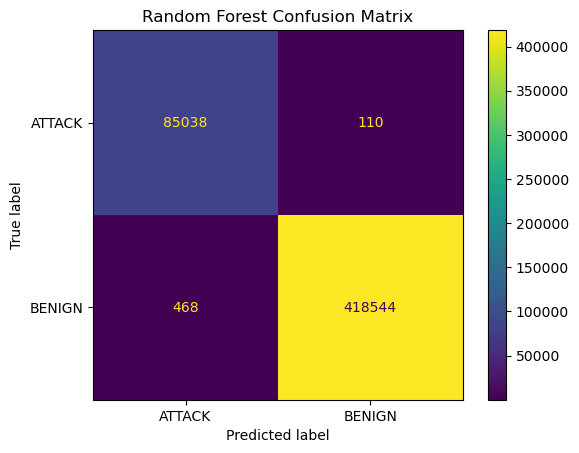

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ATTACK", "BENIGN"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

<Figure size 600x500 with 0 Axes>

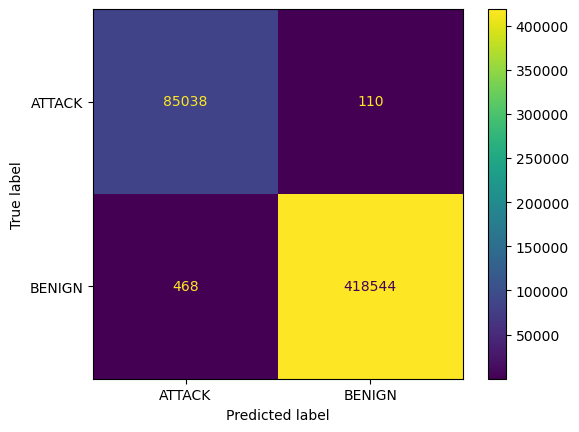

In [24]:
plt.figure(figsize=(6,5))
disp.plot()
plt.savefig("../reports/cicids_confusion_matrix.png")
plt.show()

## 20. ROC-AUC Score

In [25]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9999522978337123


## 21. ROC Curve Visualization

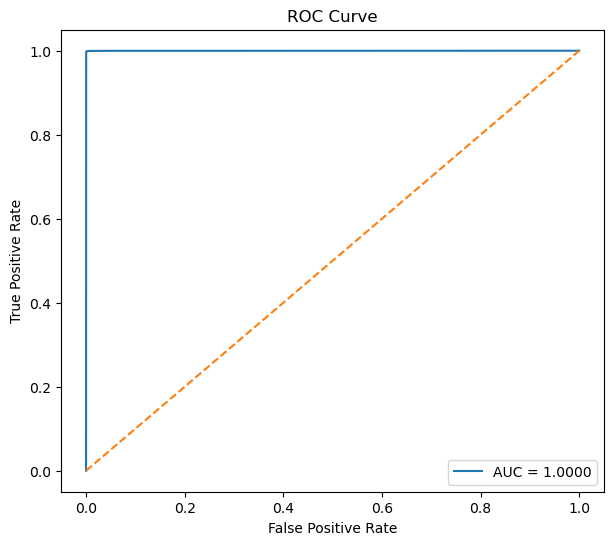

In [26]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("../reports/cicids_roc_curve.png")
plt.show()

## 22. Feature Importance Analysis

In [27]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df.head(20)

,Feature,Importance
39,Max Packet Length,0.061098
52,Average Packet Size,0.060840
41,Packet Length Std,0.057815
42,Packet Length Variance,0.056412
13,Bwd Packet Length Std,0.052571
10,Bwd Packet Length Max,0.043864
5,Total Length of Bwd Packets,0.043600
0,Destination Port,0.042819
54,Avg Bwd Segment Size,0.037563
67,Init_Win_bytes_backward,0.031629


## 23. Feature Importance Visualization

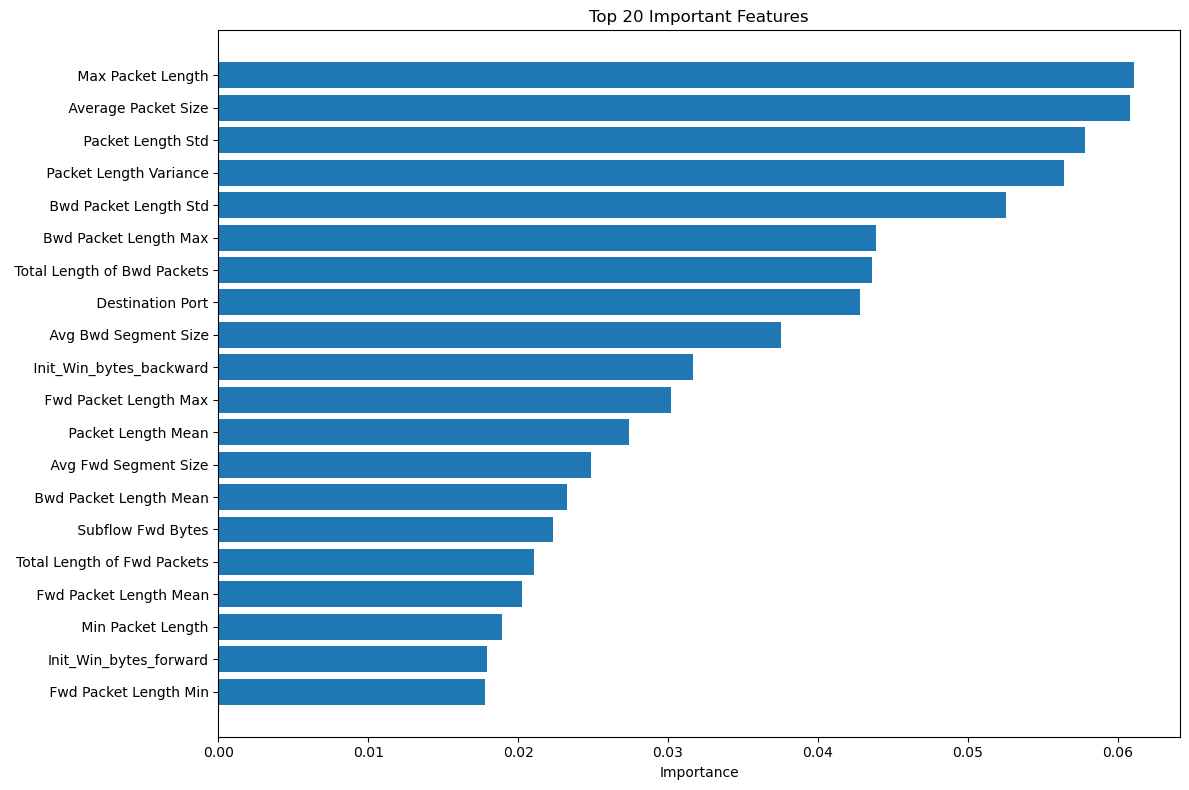

In [28]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(12,8))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../reports/cicids_feature_importance.png")
plt.show()

## 24. Save Trained Model and Label Encoder
The trained Random Forest model and label encoder are saved using Joblib.

In [29]:
import joblib

joblib.dump(rf, "../models/cicids_anomaly_model.pkl")
joblib.dump(le, "../models/cicids_label_encoder.pkl")

print("Model and label encoder saved successfully!")

Model and label encoder saved successfully!


## 25. Save Model Metrics Report
All major evaluation metrics are saved into a text report.

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

report_text = f"""
Network Anomaly Detection using CICIDS2017
Model: Random Forest Classifier

Accuracy: {accuracy_score(y_test, y_pred):.4f}
Precision: {precision_score(y_test, y_pred):.4f}
Recall: {recall_score(y_test, y_pred):.4f}
F1 Score: {f1_score(y_test, y_pred):.4f}
ROC-AUC: {auc:.4f}

Training Accuracy: {train_accuracy:.4f}
Testing Accuracy: {test_accuracy:.4f}
Difference: {train_accuracy - test_accuracy:.4f}
"""

with open("../reports/cicids_model_metrics.txt", "w") as f:
    f.write(report_text)

print("Metrics report saved successfully!")

Metrics report saved successfully!
